# Cav1.2 G402S mutation-site distance analysis
This notebook compares WT and G402S distance distributions near the G402 mutation site. Candidate distances are selected from CSV columns containing residues within ±4 positions of G402, ranked by the absolute WT-to-G402S median shift, and plotted separately for vanilla and masked protocols. Matching experimental distances are overlaid from the explicitly listed values calculated for the Cav1.2 α-subunit in 8WE6 chain A, 8HLP chain A, and 8FD7 chain K.

The final section focuses on shortest heavy-atom distances made by the introduced S402 side chain. Contact-frequency bars summarize candidate partners, and split violins compare WT G402 with mutant S402. Distances below 2 Å are flagged as atomic overlaps rather than interpreted as interactions.


In [7]:
from pathlib import Path
import importlib
import sys
repo_root = Path.cwd() if (Path.cwd() / 'shared').is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo_root)) if str(repo_root) not in sys.path else None
import shared.mutation_site_analysis as mutation_site_analysis
importlib.reload(mutation_site_analysis)  # Pick up helper changes in an already-running kernel.
load_ensemble = mutation_site_analysis.load_ensemble
nearby_distance_columns = mutation_site_analysis.nearby_distance_columns
rank_nearby_shifts = mutation_site_analysis.rank_nearby_shifts
top_aliases = mutation_site_analysis.top_aliases
plot_nearby_overlay = mutation_site_analysis.plot_nearby_overlay
from shared.dataset_selection import distance_csv_options, load_selected_distance_csv
CAV12_PALETTE = {'WT_VAN':'#DCEBF8','WT_HM':'#5E98CB','G402S_VAN':'#B8E2F0','G402S_HM':'#3C8EAA'}
G402S_EXPERIMENTAL_DISTANCES = {
    '8WE6 | chain A': {
        'CA_LEU401_CA-ILE1186_CA': [10.070], 'CA_LEU401_CA-VAL753_CA': [11.718], 'GLY406-MET1524': [7.404],
        'LEU401-ALA1521': [9.341], 'LEU401-ASN1526': [9.824], 'LEU401-ASP1525': [10.976], 'LEU401-ASP1528': [11.996], 'LEU401-ASP1533': [14.828],
        'LEU401-MET1524': [8.529], 'LEU401-TYR1529': [10.879], 'LEU401-VAL1522': [8.829], 'LEU404-MET1524': [9.680],
        'SER405-ASP1525': [9.391], 'SER405-ASP1533': [11.521], 'SER405-MET1524': [6.077], 'SER405-TYR1529': [9.355],
        'VAL400-ASP1528': [13.981], 'VAL400-MET1524': [11.185], 'VAL403-ASP1528': [10.703], 'VAL403-MET1524': [9.090],
    },
    '8HLP | chain A': {
        'CA_LEU401_CA-ILE1186_CA': [9.986], 'CA_LEU401_CA-VAL753_CA': [11.751], 'GLY406-MET1524': [8.961],
        'LEU401-ALA1521': [9.471], 'LEU401-ASN1526': [9.889], 'LEU401-ASP1525': [11.505], 'LEU401-ASP1528': [11.921], 'LEU401-ASP1533': [14.849],
        'LEU401-MET1524': [9.147], 'LEU401-TYR1529': [10.943], 'LEU401-VAL1522': [8.975], 'LEU404-MET1524': [11.400],
        'SER405-ASP1525': [9.994], 'SER405-ASP1533': [11.415], 'SER405-MET1524': [7.551], 'SER405-TYR1529': [9.544],
        'VAL400-ASP1528': [14.009], 'VAL400-MET1524': [11.875], 'VAL403-ASP1528': [10.726], 'VAL403-MET1524': [9.957],
    },
    '8FD7 | chain K': {
        'CA_LEU401_CA-ILE1186_CA': [13.653], 'CA_LEU401_CA-VAL753_CA': [15.182], 'GLY406-MET1524': [13.416],
        'LEU401-ALA1521': [7.614], 'LEU401-ASN1526': [3.233], 'LEU401-ASP1525': [7.669], 'LEU401-ASP1528': [8.778], 'LEU401-ASP1533': [11.673],
        'LEU401-MET1524': [6.187], 'LEU401-TYR1529': [8.138], 'LEU401-VAL1522': [5.311], 'LEU404-MET1524': [8.234],
        'SER405-ASP1525': [11.258], 'SER405-ASP1533': [7.884], 'SER405-MET1524': [10.802], 'SER405-TYR1529': [6.804],
        'VAL400-ASP1528': [13.343], 'VAL400-MET1524': [11.054], 'VAL403-ASP1528': [13.659], 'VAL403-MET1524': [13.091],
    },
}
G402S_EXPERIMENTAL_DISTANCES


{'8WE6 | chain A': {'CA_LEU401_CA-ILE1186_CA': [10.07],
  'CA_LEU401_CA-VAL753_CA': [11.718],
  'GLY406-MET1524': [7.404],
  'LEU401-ALA1521': [9.341],
  'LEU401-ASN1526': [9.824],
  'LEU401-ASP1525': [10.976],
  'LEU401-ASP1528': [11.996],
  'LEU401-ASP1533': [14.828],
  'LEU401-MET1524': [8.529],
  'LEU401-TYR1529': [10.879],
  'LEU401-VAL1522': [8.829],
  'LEU404-MET1524': [9.68],
  'SER405-ASP1525': [9.391],
  'SER405-ASP1533': [11.521],
  'SER405-MET1524': [6.077],
  'SER405-TYR1529': [9.355],
  'VAL400-ASP1528': [13.981],
  'VAL400-MET1524': [11.185],
  'VAL403-ASP1528': [10.703],
  'VAL403-MET1524': [9.09]},
 '8HLP | chain A': {'CA_LEU401_CA-ILE1186_CA': [9.986],
  'CA_LEU401_CA-VAL753_CA': [11.751],
  'GLY406-MET1524': [8.961],
  'LEU401-ALA1521': [9.471],
  'LEU401-ASN1526': [9.889],
  'LEU401-ASP1525': [11.505],
  'LEU401-ASP1528': [11.921],
  'LEU401-ASP1533': [14.849],
  'LEU401-MET1524': [9.147],
  'LEU401-TYR1529': [10.943],
  'LEU401-VAL1522': [8.975],
  'LEU404-MET1524'

In [8]:
DATASET_SELECTION = 'all_ok_3'  # Corrected 3 Å convergence subset stored in cav12/dataDistances; switch to 'all' to inspect unfiltered rows.
data = repo_root / 'cav12' / 'dataDistances'
DATASET_PATHS = {
    'WT vanilla': distance_csv_options(repo_root, data / '26-02-10_Cav12_wt_vanillaAF2_distances_all.csv', 'Cav12', 'WT', 'vanilla'),
    'WT masked': distance_csv_options(repo_root, data / '26-02-10_Cav12_wt_maskedAF2_distances_all.csv', 'Cav12', 'WT', 'masked'),
    'G402S vanilla': distance_csv_options(repo_root, data / '26-02-10_Cav12_g402s_vanillaAF2_distances_all.csv', 'Cav12', 'G402S', 'vanilla'),
    'G402S masked': distance_csv_options(repo_root, data / '26-02-10_Cav12_g402s_maskedAF2_distances_all.csv', 'Cav12', 'G402S', 'masked'),
}
DATASET_PATHS
wt_van = load_selected_distance_csv('WT vanilla', DATASET_PATHS['WT vanilla'], DATASET_SELECTION)
wt_mask = load_selected_distance_csv('WT masked', DATASET_PATHS['WT masked'], DATASET_SELECTION)
mut_van = load_selected_distance_csv('G402S vanilla', DATASET_PATHS['G402S vanilla'], DATASET_SELECTION)
mut_mask = load_selected_distance_csv('G402S masked', DATASET_PATHS['G402S masked'], DATASET_SELECTION)
structures = {'8WE6 | chain A': (repo_root / 'cav12' / 'experimentals' / '8WE6.pdb', 'A'), '8HLP | chain A': (repo_root / 'cav12' / 'experimentals' / '8HLP.pdb', 'A'), '8FD7 | chain K': (repo_root / 'cav12' / 'experimentals' / '8FD7.pdb', 'K')}
experimental_colors = {'8WE6 | chain A':'#D55E00','8HLP | chain A':'#0072B2','8FD7 | chain K':'#009E73'}


WT vanilla: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_wt_vanillaAF2_distances_all_ok_rmsd_3A.csv
WT masked: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_wt_maskedAF2_distances_all_ok_rmsd_3A.csv
G402S vanilla: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_g402s_vanillaAF2_distances_all_ok_rmsd_3A.csv
G402S masked: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_g402s_maskedAF2_distances_all_ok_rmsd_3A.csv


,distance,wt_median_A,mutant_median_A,median_shift_A,abs_shift_A
15,shortest_VAL400-MET1524,10.9,12.0,1.1,1.1
100,shortest_GLY406-MET1524,6.5,7.5,1.0,1.0
33,shortest_LEU401-ASP1525,14.4,13.4,-1.0,1.0
29,shortest_LEU401-ALA1521,9.9,8.9,-1.0,1.0
36,shortest_LEU401-ASP1528,12.3,11.6,-0.7,0.7
30,shortest_LEU401-VAL1522,13.3,12.6,-0.7,0.7
32,shortest_LEU401-MET1524,6.7,6.0,-0.7,0.7
19,shortest_VAL400-ASP1528,14.1,13.4,-0.7,0.7
37,shortest_LEU401-TYR1529,22.2,21.5,-0.7,0.7
49,shortest_VAL403-MET1524,9.4,10.0,0.6,0.6


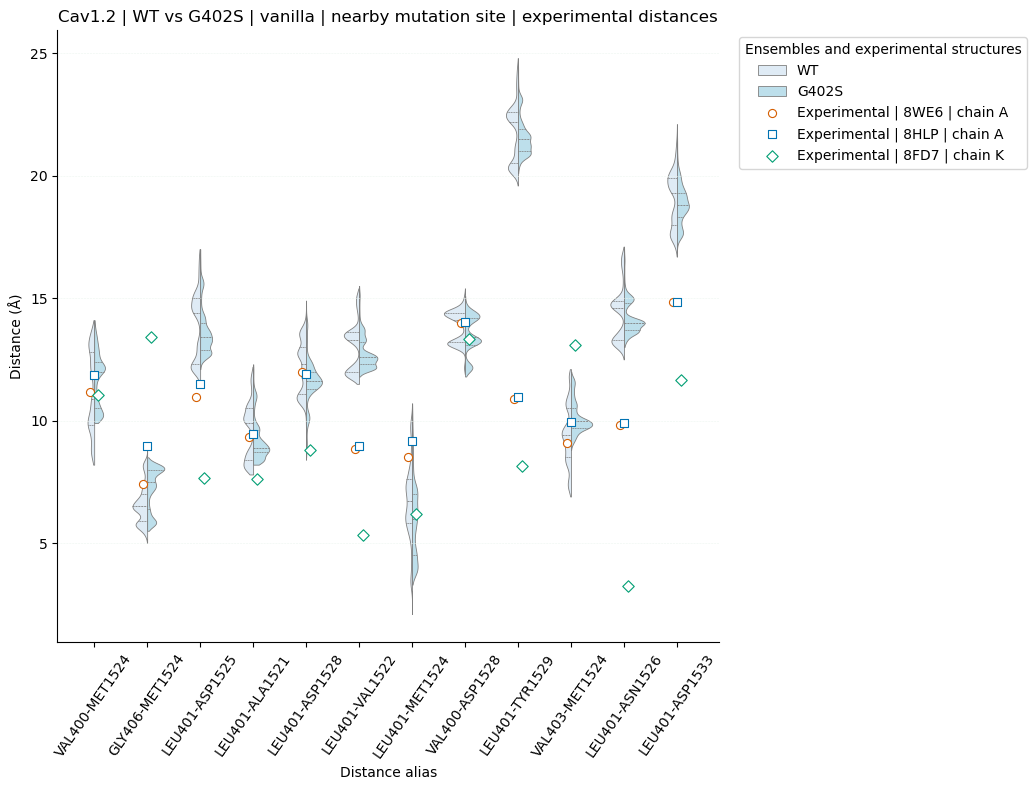

,distance,wt_median_A,mutant_median_A,median_shift_A,abs_shift_A
15,shortest_VAL400-MET1524,10.40,12.60,2.20,2.20
49,shortest_VAL403-MET1524,8.30,10.00,1.70,1.70
100,shortest_GLY406-MET1524,5.80,7.20,1.40,1.40
66,shortest_LEU404-MET1524,9.70,10.80,1.10,1.10
83,shortest_SER405-MET1524,4.00,4.90,0.90,0.90
1,CA_LEU401_CA-VAL753_CA,12.06,12.92,0.86,0.86
4,CA_LEU401_CA-ILE1186_CA,13.01,13.64,0.63,0.63
0,CA_LEU401_CA-LEU749_CA,9.05,9.65,0.60,0.60
92,shortest_SER405-ASP1533,14.80,15.40,0.60,0.60
29,shortest_LEU401-ALA1521,11.10,11.70,0.60,0.60


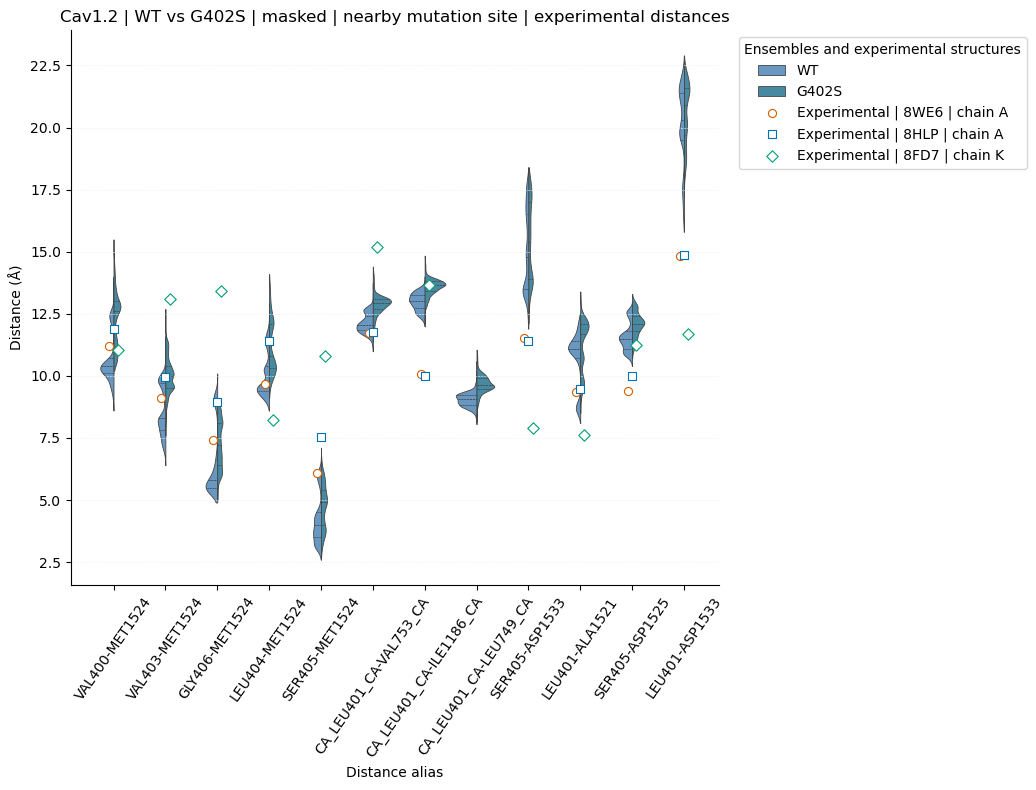

In [9]:
for protocol, wt, mutant, colors in [('vanilla', wt_van, mut_van, (CAV12_PALETTE['WT_VAN'], CAV12_PALETTE['G402S_VAN'])), ('masked', wt_mask, mut_mask, (CAV12_PALETTE['WT_HM'], CAV12_PALETTE['G402S_HM']))]:
    shifts = rank_nearby_shifts(wt, mutant, nearby_distance_columns(wt, 402))
    display(shifts.head(20))
    aliases = top_aliases(shifts)
    experimentals = {structure: {alias: values for alias, values in distances.items() if alias in aliases} for structure, distances in G402S_EXPERIMENTAL_DISTANCES.items()}
    plot_nearby_overlay(wt, mutant, aliases, 'Cav1.2', 'G402S', protocol, colors, experimentals, experimental_colors)

## Contacts made by the introduced S402 side chain
from shared.mutation_contact_analysis import plot_mutation_contacts, plot_selected_contact_distributions
g402s_contact_table, _ = plot_mutation_contacts(
    {'vanilla': (wt_van, mut_van), 'masked': (wt_mask, mut_mask)},
    'GLY402', 'SER402', 'G402S',
    {'vanilla': CAV12_PALETTE['G402S_VAN'], 'masked': CAV12_PALETTE['G402S_HM']},
)
display(g402s_contact_table.head(15).round(3))
plot_selected_contact_distributions(
    {'vanilla': (wt_van, mut_van), 'masked': (wt_mask, mut_mask)},
    'GLY402', 'SER402', 'G402S', ['ILE1523', 'MET1524', 'ASP1528'],
    {'vanilla': (CAV12_PALETTE['WT_VAN'], CAV12_PALETTE['G402S_VAN']), 'masked': (CAV12_PALETTE['WT_HM'], CAV12_PALETTE['G402S_HM'])},
)
